# Query Demo

Examples of using the `bible_grammar` query API.

In [1]:
import sys
sys.path.insert(0, '../../../src')
import matplotlib.pyplot as plt
from bible_grammar.query import query, reload
from bible_grammar import stats, charts
reload()
%matplotlib inline

## Hebrew: Niphal Perfect verbs by book

In [2]:
nip = stats.niphal_perfects_by_book()
print(f"Total Niphal Perfects: {nip['count'].sum()}")
nip.head(10)

Total Niphal Perfects: 2601


,book_id,count
0,Jer,286
1,Isa,255
2,Ezk,207
3,Lev,137
4,Gen,136
5,1Sa,122
6,Exo,117
7,Num,113
8,Pro,95
9,Deu,95


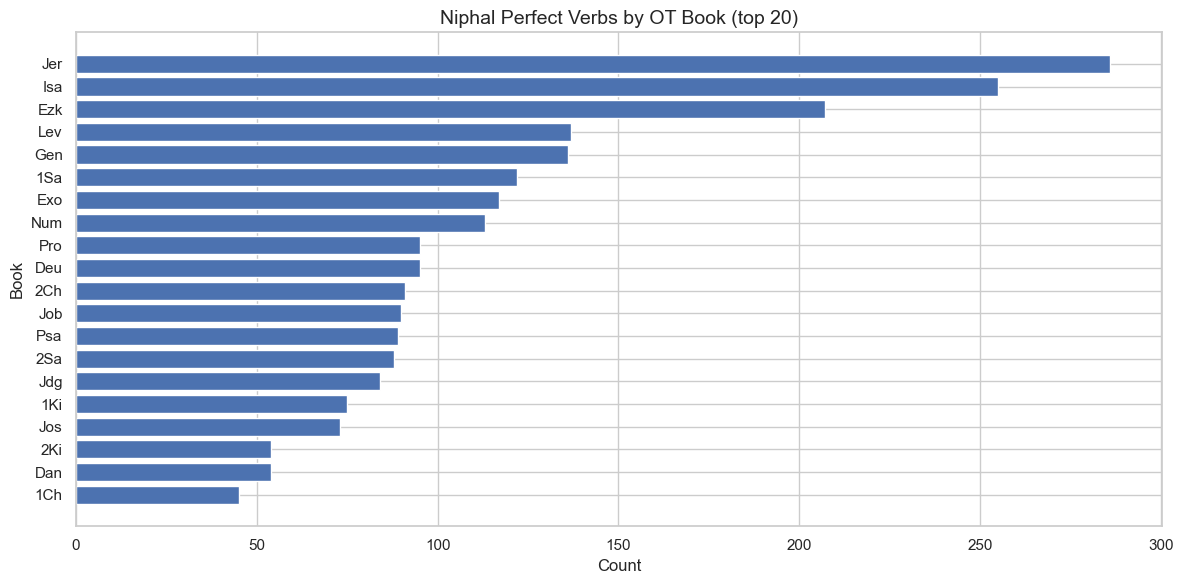

In [3]:
fig = charts.bar_chart(
    nip, x='book_id',
    title='Niphal Perfect Verbs by OT Book (top 20)',
    xlabel='Book', top_n=20,
    output_path='../../../output/charts/ot/verbs/niphal_perfects_by_book.png'
)
plt.show()

## Hebrew: Verb stem distribution in Genesis

In [4]:
gen_stems = stats.verb_stems_by_book(book='Gen')
gen_stems

,book_id,stem,count
0,Gen,Qal,3530
1,Gen,Hiphil,395
2,Gen,,334
3,Gen,Piel,279
4,Gen,Niphal,193
5,Gen,Hithpael,44
6,Gen,Pual,28
7,Gen,Haphel,21
8,Gen,Hophal,21


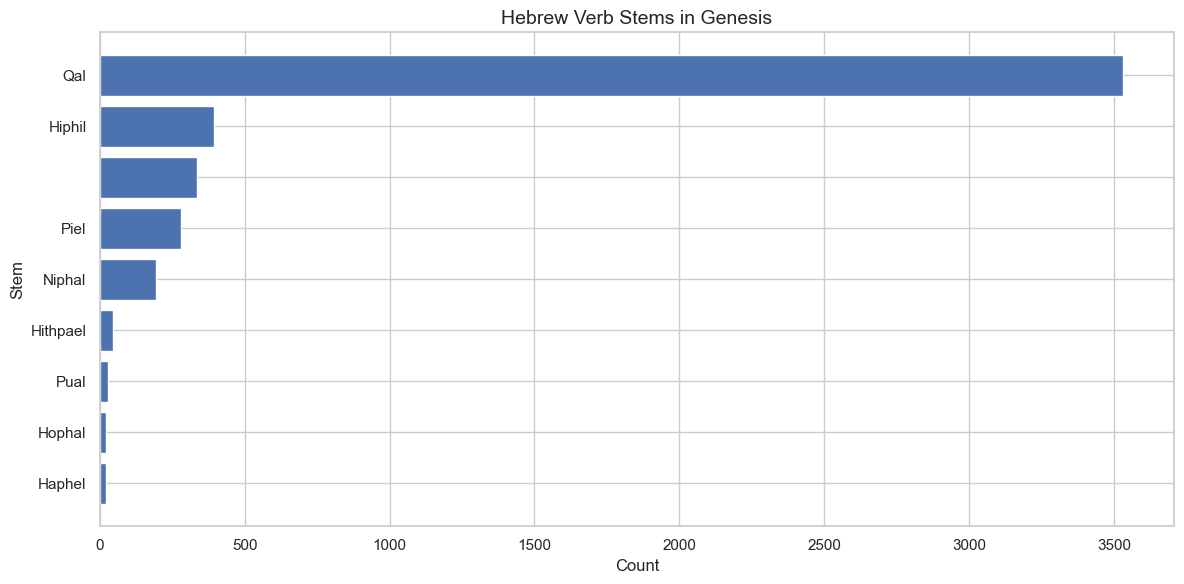

In [5]:
fig = charts.bar_chart(
    gen_stems, x='stem',
    title='Hebrew Verb Stems in Genesis',
    xlabel='Stem', top_n=None,
    output_path='../../../output/charts/ot/verbs/genesis_verb_stems.png'
)
plt.show()

## Greek: Tense × Voice heatmap in Paul's letters

In [6]:
paul_verbs = stats.greek_verb_forms(book_group='pauline')
paul_verbs.head(15)

,tense,voice,mood,count
0,Present,Active,Indicative,1169
1,Present,Active,Participle,597
2,,,,555
3,Aorist,Active,Indicative,322
4,Present,Active,Imperative,221
5,Present,Active,Infinitive,217
6,Future,Active,Indicative,165
7,2nd Aorist,Active,Indicative,158
8,Present,N,Indicative,153
9,Present,Active,Subjunctive,146


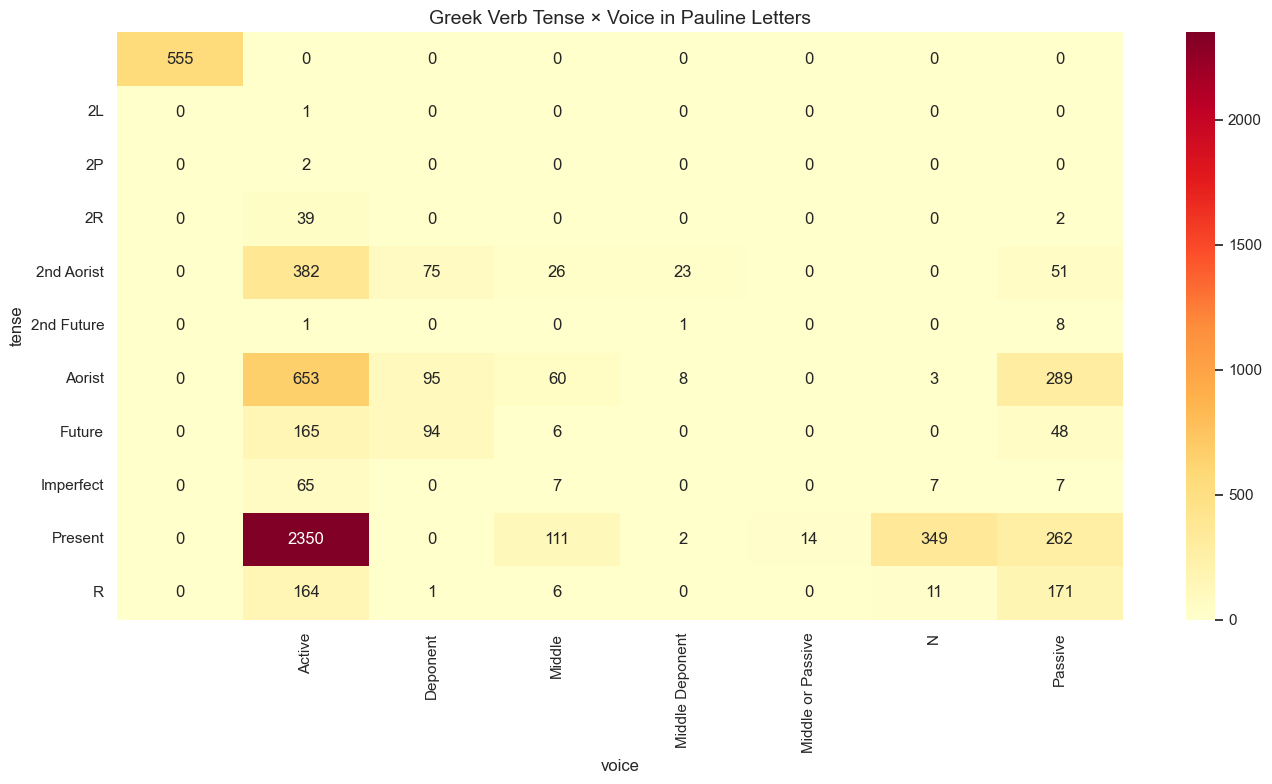

In [7]:
# Aggregate tense x voice ignoring mood for the heatmap
import pandas as pd
tv = paul_verbs.groupby(['tense','voice'])['count'].sum().reset_index()
fig = charts.heatmap(
    tv, index='tense', columns='voice',
    title="Greek Verb Tense × Voice in Pauline Letters",
    output_path='../../../output/charts/nt/verbs/pauline_tense_voice.png'
)
plt.show()

## Ad-hoc: Qal imperatives in the Torah

In [8]:
imperatives = query(book_group='torah', stem='Qal', conjugation='Imperative')
print(f"Qal Imperatives in Torah: {len(imperatives)}")
by_book = imperatives.groupby('book_id').size().reset_index(name='count').sort_values('count', ascending=False)
by_book

Qal Imperatives in Torah: 451


,book_id,count
2,Gen,181
1,Exo,120
0,Deu,75
4,Num,64
3,Lev,11


## Export results to CSV

In [9]:
nip_detail = query(stem='Niphal', conjugation='Perfect')
nip_detail.to_csv('../output/exports/niphal_perfects.csv', index=False)
print(f"Saved {len(nip_detail)} rows to output/exports/niphal_perfects.csv")

Saved 2601 rows to output/exports/niphal_perfects.csv
